In [11]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

customers_features= pd.read_csv(r'C:\Users\l\Documents\DATA_SCIENCE_KURS\PROJEKT_PREDYCJI_SUBSKRYBCJI_NEWSLETTERA\PROJEKT\b_oprzadek\data\customers_features.csv')

customers_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            1000 non-null   str    
 1   name                   1000 non-null   str    
 2   age                    1000 non-null   int64  
 3   state                  1000 non-null   str    
 4   signup_date            1000 non-null   str    
 5   email                  1000 non-null   str    
 6   phone_number           1000 non-null   int64  
 7   subscribe              1000 non-null   int64  
 8   customer_tenture_days  1000 non-null   int64  
 9   gender_Male            1000 non-null   bool   
 10  transaction_count      1000 non-null   int64  
 11  total_spent            1000 non-null   int64  
 12  avg_transaction_value  1000 non-null   float64
 13  total_quantity         1000 non-null   int64  
 14  avg_discount           1000 non-null   float64
 15  unique_products 

## Statystyki opisowe

In [12]:
numeric_features = [
    "age",
    "customer_tenture_days",
    "transaction_count",
    "total_spent",
    "avg_transaction_value",
    "total_quantity",
    "unique_products",
    "avg_discount",
    "subscribe"
]

customers_features[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,4.119200e+01,1.348306e+01,18.0,2.900000e+01,42.00,5.200000e+01,65.0
customer_tenture_days,1000.0,3.649610e+02,2.053289e+02,0.0,1.887500e+02,367.00,5.330000e+02,730.0
transaction_count,1000.0,8.199000e+00,4.430240e+00,1.0,4.000000e+00,8.00,1.200000e+01,27.0
total_spent,1000.0,5.579279e+07,3.966467e+07,8400.0,2.379925e+07,48816500.00,8.186850e+07,250201000.0
avg_transaction_value,1000.0,6.802236e+06,3.408847e+06,8400.0,4.139714e+06,6969222.22,8.723183e+06,48790000.0
total_quantity,1000.0,1.834630e+02,1.144793e+02,1.0,8.900000e+01,167.50,2.650000e+02,753.0
unique_products,1000.0,8.199000e+00,4.430240e+00,1.0,4.000000e+00,8.00,1.200000e+01,27.0
avg_discount,1000.0,2.364653e+01,6.738927e+00,0.0,2.000000e+01,23.42,2.725500e+01,50.0
subscribe,1000.0,7.110000e-01,4.535247e-01,0.0,0.000000e+00,1.00,1.000000e+00,1.0


In [13]:
print(
    customers_features["total_spent"]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)

count    1.000000e+03
mean     5.579279e+07
std      3.966467e+07
min      8.400000e+03
10%      1.045093e+07
25%      2.379925e+07
50%      4.881650e+07
75%      8.186850e+07
90%      1.110372e+08
95%      1.291064e+08
99%      1.615879e+08
max      2.502010e+08
Name: total_spent, dtype: float64


In [35]:
customers_features.groupby("subscribe")[
    ["age", "customer_tenture_days", "transaction_count", "total_spent", "unique_products"]
].agg(["mean", "median"]).T

subscribe                                0             1
age                   mean    4.121107e+01  4.118425e+01
                      median  4.200000e+01  4.200000e+01
customer_tenture_days mean    3.609412e+02  3.665949e+02
                      median  3.620000e+02  3.670000e+02
transaction_count     mean    8.211073e+00  8.194093e+00
                      median  8.000000e+00  8.000000e+00
total_spent           mean    2.648194e+07  6.770677e+07
                      median  2.479000e+07  6.361000e+07
unique_products       mean    8.211073e+00  8.194093e+00
                      median  8.000000e+00  8.000000e+00

In [36]:
customers_features.corr(numeric_only=True)["subscribe"].sort_values(ascending=False)

subscribe                1.000000
avg_transaction_value    0.680035
total_spent              0.471364
total_quantity           0.421283
customer_tenture_days    0.012488
gender_Male              0.010243
avg_discount             0.004620
age                     -0.000902
transaction_count       -0.001738
unique_products         -0.001738
phone_number            -0.098146
Name: subscribe, dtype: float64

## Wizualizacje

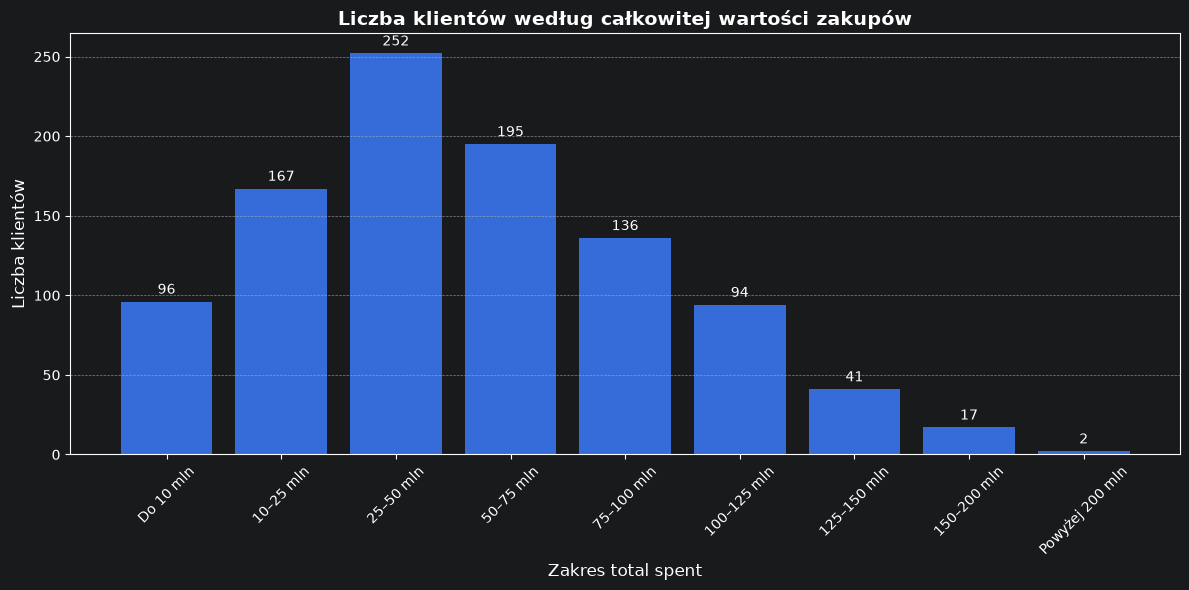

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Definiujemy przedziały
bins = [
    0,
    10_000_000,
    25_000_000,
    50_000_000,
    75_000_000,
    100_000_000,
    125_000_000,
    150_000_000,
    200_000_000,
    float("inf")
]

# Etykiety przedziałów
labels = [
    "Do 10 mln",
    "10–25 mln",
    "25–50 mln",
    "50–75 mln",
    "75–100 mln",
    "100–125 mln",
    "125–150 mln",
    "150–200 mln",
    "Powyżej 200 mln"
]

# Przypisanie klientów do przedziałów
customer_spending_groups = pd.cut(
    customers_features["total_spent"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Liczba klientów w każdym przedziale
customer_counts = customer_spending_groups.value_counts(
    sort=False
)

# Tworzenie wykresu
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    customer_counts.index,
    customer_counts.values
)

# Tytuł
ax.set_title(
    "Liczba klientów według całkowitej wartości zakupów",
    fontsize=14,
    fontweight="bold"
)

# Osie
ax.set_xlabel(
    "Zakres total spent",
    fontsize=12
)

ax.set_ylabel(
    "Liczba klientów",
    fontsize=12
)

# Liczby nad słupkami
for i, value in enumerate(customer_counts.values):
    ax.text(
        i,
        value + 5,
        str(value),
        ha="center"
    )

# Siatka
ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.7
)

# Obrót etykiet
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

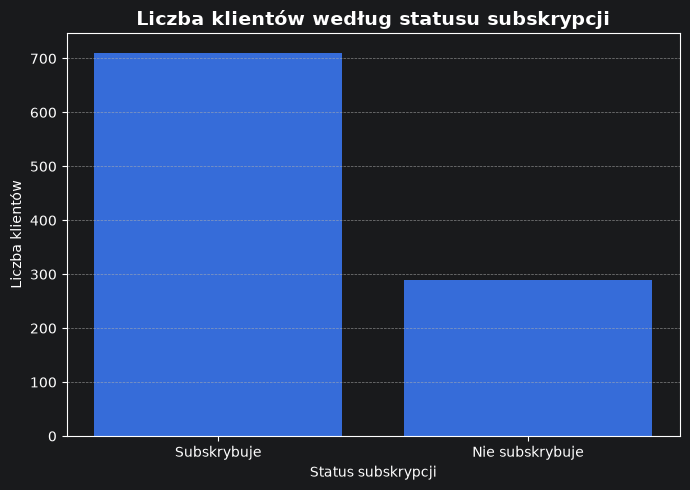

In [15]:
subscribe_counts = customers_features["subscribe"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    ["Subskrybuje", "Nie subskrybuje"],
    subscribe_counts.values
)

ax.set_title(
    "Liczba klientów według statusu subskrypcji",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Status subskrypcji")
ax.set_ylabel("Liczba klientów")

ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()

In [16]:
customers_features['subscribe'].sum()

np.int64(711)

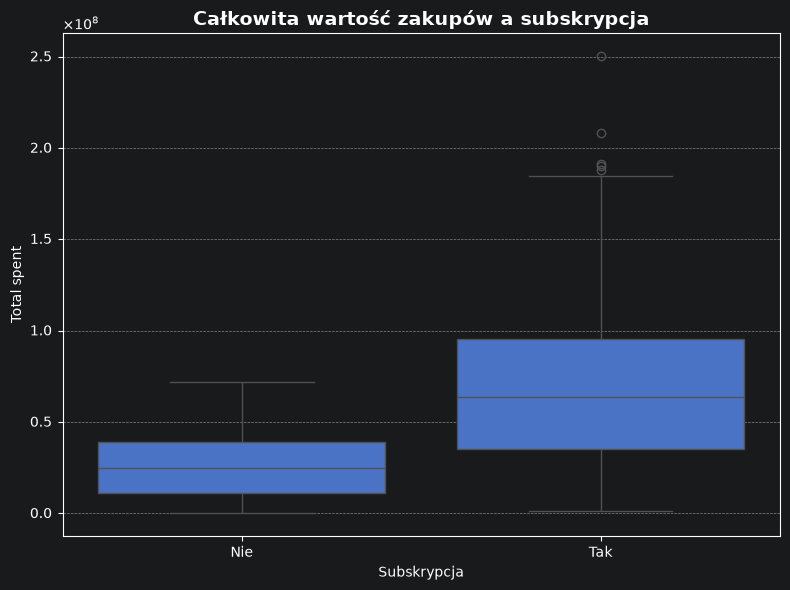

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=customers_features,
    x="subscribe",
    y="total_spent",
    ax=ax
)

# Ustawienie pozycji ticków
ax.set_xticks([0, 1])

# Ustawienie nazw kategorii
ax.set_xticklabels(["Nie", "Tak"])

ax.set_title(
    "Całkowita wartość zakupów a subskrypcja",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Subskrypcja")
ax.set_ylabel("Total spent")

# Formatowanie osi Y
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

ax.yaxis.set_major_formatter(formatter)

# Siatka
ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()

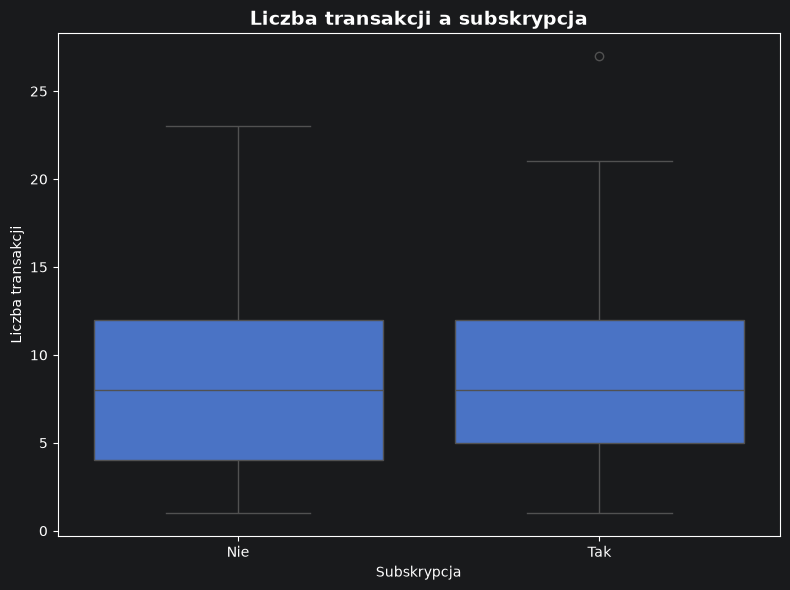

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=customers_features,
    x="subscribe",
    y="transaction_count",
    ax=ax
)
# Ustawienie pozycji ticków
ax.set_xticks([0, 1])

# Ustawienie nazw kategorii
ax.set_xticklabels(["Nie", "Tak"])

ax.set_title(
    "Liczba transakcji a subskrypcja",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Subskrypcja")
ax.set_ylabel("Liczba transakcji")

plt.tight_layout()
plt.show()

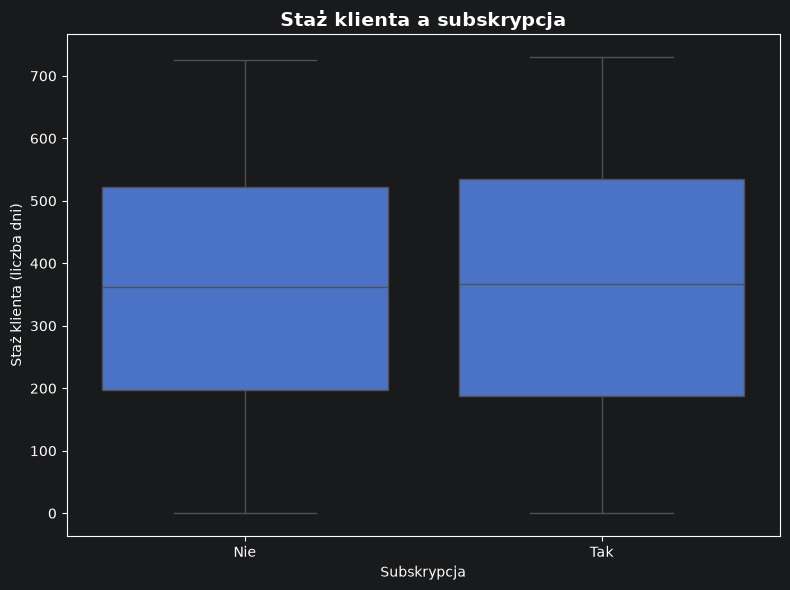

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=customers_features,
    x="subscribe",
    y="customer_tenture_days",
    ax=ax
)
# Ustawienie pozycji ticków
ax.set_xticks([0, 1])

# Ustawienie nazw kategorii
ax.set_xticklabels(["Nie", "Tak"])
ax.set_title(
    "Staż klienta a subskrypcja",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Subskrypcja")
ax.set_ylabel("Staż klienta (liczba dni)")

plt.tight_layout()
plt.show()

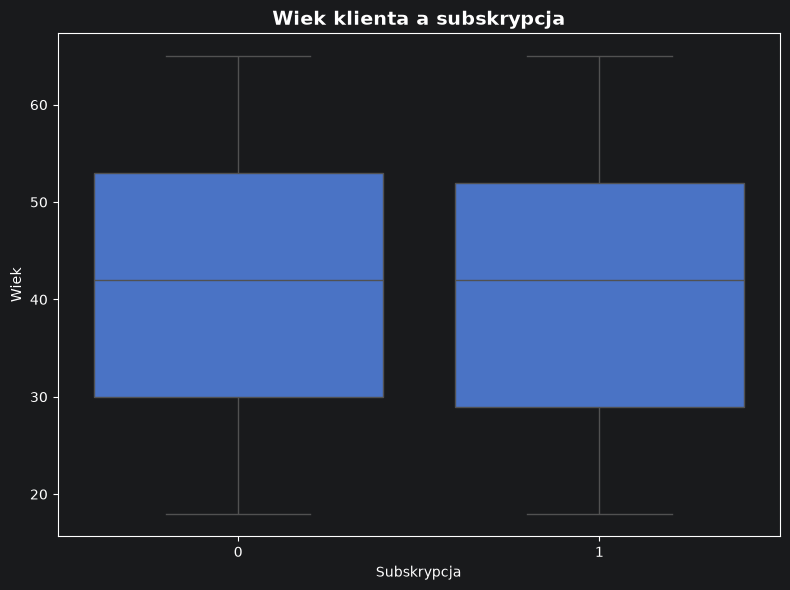

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=customers_features,
    x="subscribe",
    y="age",
    ax=ax
)

ax.set_title(
    "Wiek klienta a subskrypcja",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Subskrypcja")
ax.set_ylabel("Wiek")

plt.tight_layout()
plt.show()

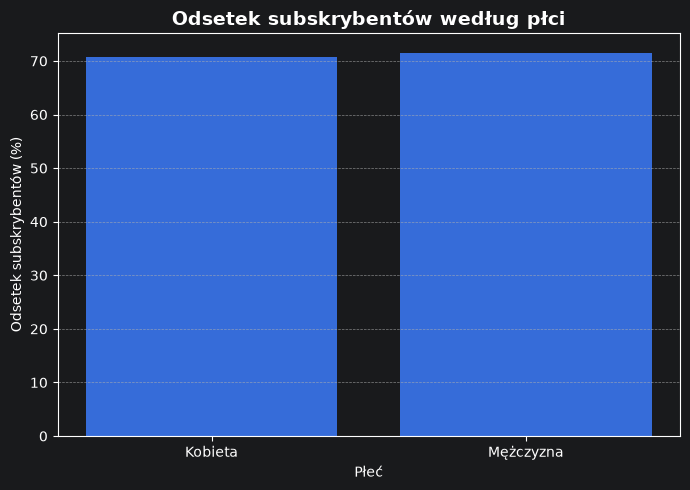

In [31]:
import matplotlib.pyplot as plt

# Obliczamy odsetek subskrybentów dla każdej wartości gender_male
gender_subscribe = (
    customers_features
    .groupby("gender_Male")["subscribe"]
    .mean()
)

# Tworzymy wykres
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    ["Kobieta", "Mężczyzna"],
    gender_subscribe.values * 100
)

ax.set_title(
    "Odsetek subskrybentów według płci",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Płeć")
ax.set_ylabel("Odsetek subskrybentów (%)")

ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()

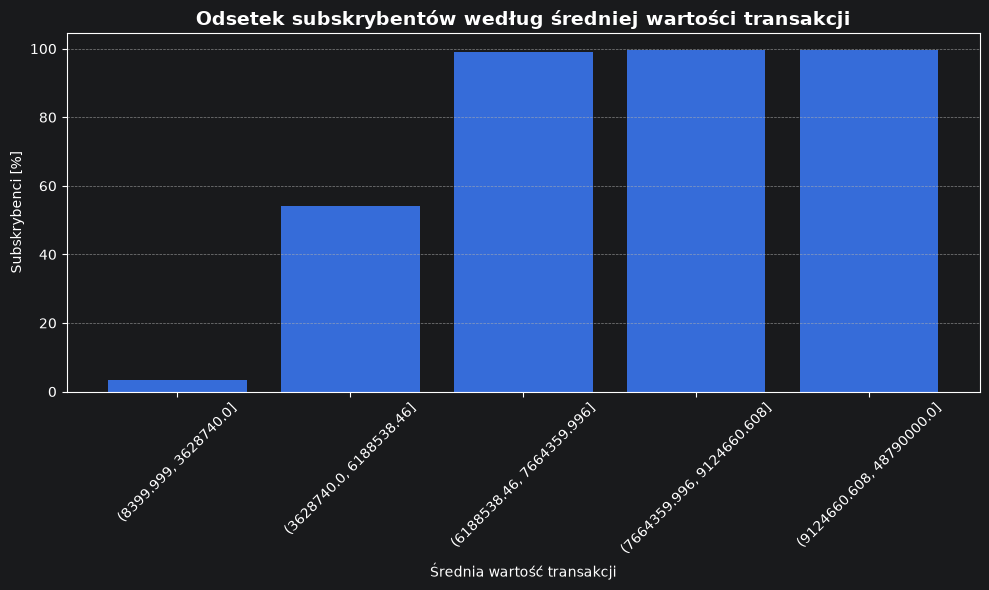

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Tworzymy 5 grup klientów według średniej wartości transakcji
customers_features["avg_transaction_group"] = pd.qcut(
    customers_features["avg_transaction_value"],
    q=5,
    duplicates="drop"
)

# Obliczamy procent subskrybentów w każdej grupie
subscribe_by_avg_value = (
    customers_features
    .groupby("avg_transaction_group", observed=True)["subscribe"]
    .mean() * 100
)

# Tworzymy wykres
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    subscribe_by_avg_value.index.astype(str),
    subscribe_by_avg_value.values
)

ax.set_title(
    "Odsetek subskrybentów według średniej wartości transakcji",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Średnia wartość transakcji")
ax.set_ylabel("Subskrybenci [%]")

ax.tick_params(axis="x", rotation=45)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()

## Detekcja outlierów metodą IQR

In [ ]:
def detect_outliers_iqr(df, columns):
    outlier_summary = {}

    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[
            (df[column] < lower_bound) |
            (df[column] > upper_bound)
        ]

        outlier_summary[column] = {
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": len(outliers)
        }

    return pd.DataFrame(outlier_summary).T

outlier_summary = detect_outliers_iqr(
    customers_features,
    numeric_features
)

print(outlier_summary)

## Podsumowanie

W pierwszym etapie przeprowadzono kontrolę jakości danych w tabelach customers i transactions. Usunięto zduplikowane rekordy klientów, które były identycznymi kopiami. Braki w zmiennej age uzupełniono medianą, natomiast braki w pozostałych kolumnach przeanalizowano pod kątem ich znaczenia biznesowego.

Poprawiono typy danych, m.in. przekonwertowano kolumny zawierające daty na typ datetime, a wybrane zmienne tekstowe na typ category. Zmienną docelową subscribe zakodowano binarnie jako 0/1.

Następnie wykonano feature engineering. Na podstawie danych transakcyjnych utworzono m.in. wartość pojedynczej transakcji, liczbę transakcji klienta, całkowitą wartość zakupów, średnią wartość transakcji, łączną liczbę zakupionych sztuk oraz liczbę unikalnych produktów. Dane transakcyjne zagregowano do poziomu customer_id i połączono z tabelą klientów, uzyskując jedną tabelę analityczną, w której jeden wiersz odpowiada jednemu klientowi.

W ramach eksploracyjnej analizy danych obliczono statystyki opisowe dla kluczowych zmiennych liczbowych oraz przeanalizowano rozkłady zmiennych, zależności między cechami a zmienną docelową subscribe oraz korelacje pomiędzy zmiennymi liczbowymi. Przeprowadzono również detekcję wartości odstających metodą IQR. Wartości odstające nie są automatycznie usuwane, ponieważ mogą reprezentować rzeczywiste zachowania klientów. Ich wpływ na model zostanie oceniony na dalszym etapie.